In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n-cls.pt')

results = model.train(
    data='/content/drive/MyDrive/Drowsiness-detection/small',
    epochs=10,
    imgsz=224,
    batch=32,
    device=0,
    project='/content/drive/MyDrive/Drowsiness-detection/runs',
    name='drowsiness_model',
    patience=5
)

print("Training complete!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Drowsiness-detection/small, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

results_path = '/content/drive/MyDrive/Drowsiness-detection/runs/drowsiness_model'

print("Files in results folder:")
for item in os.listdir(results_path):
    print(item)

Files in results folder:
weights
args.yaml
train_batch0.jpg
train_batch2.jpg
train_batch1.jpg
val_batch0_pred.jpg
val_batch0_labels.jpg
val_batch1_pred.jpg
val_batch1_labels.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
results.csv
confusion_matrix_normalized.png
confusion_matrix.png
results.png


In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Drowsiness-detection/runs/drowsiness_model/results.csv')

# Clean column names
df.columns = df.columns.str.strip()

print("Training Results:")
print(df.to_string())

Training Results:
   epoch     time  train/loss  metrics/accuracy_top1  metrics/accuracy_top5  val/loss    lr/pg0    lr/pg1    lr/pg2
0      1   80.627     0.39159                  0.984                      1   0.05157  0.000553  0.000553  0.000553
1      2  157.876     0.11618                  0.948                      1   0.16250  0.000999  0.000999  0.000999
2      3  233.482     0.09680                  0.984                      1   0.04383  0.001335  0.001335  0.001335
3      4  308.495     0.05851                  1.000                      1   0.00284  0.001172  0.001172  0.001172
4      5  384.865     0.05622                  0.999                      1   0.00523  0.001007  0.001007  0.001007
5      6  462.719     0.03285                  0.999                      1   0.00304  0.000842  0.000842  0.000842
6      7  538.894     0.02458                  0.999                      1   0.00315  0.000677  0.000677  0.000677
7      8  615.224     0.01771                  0.999  

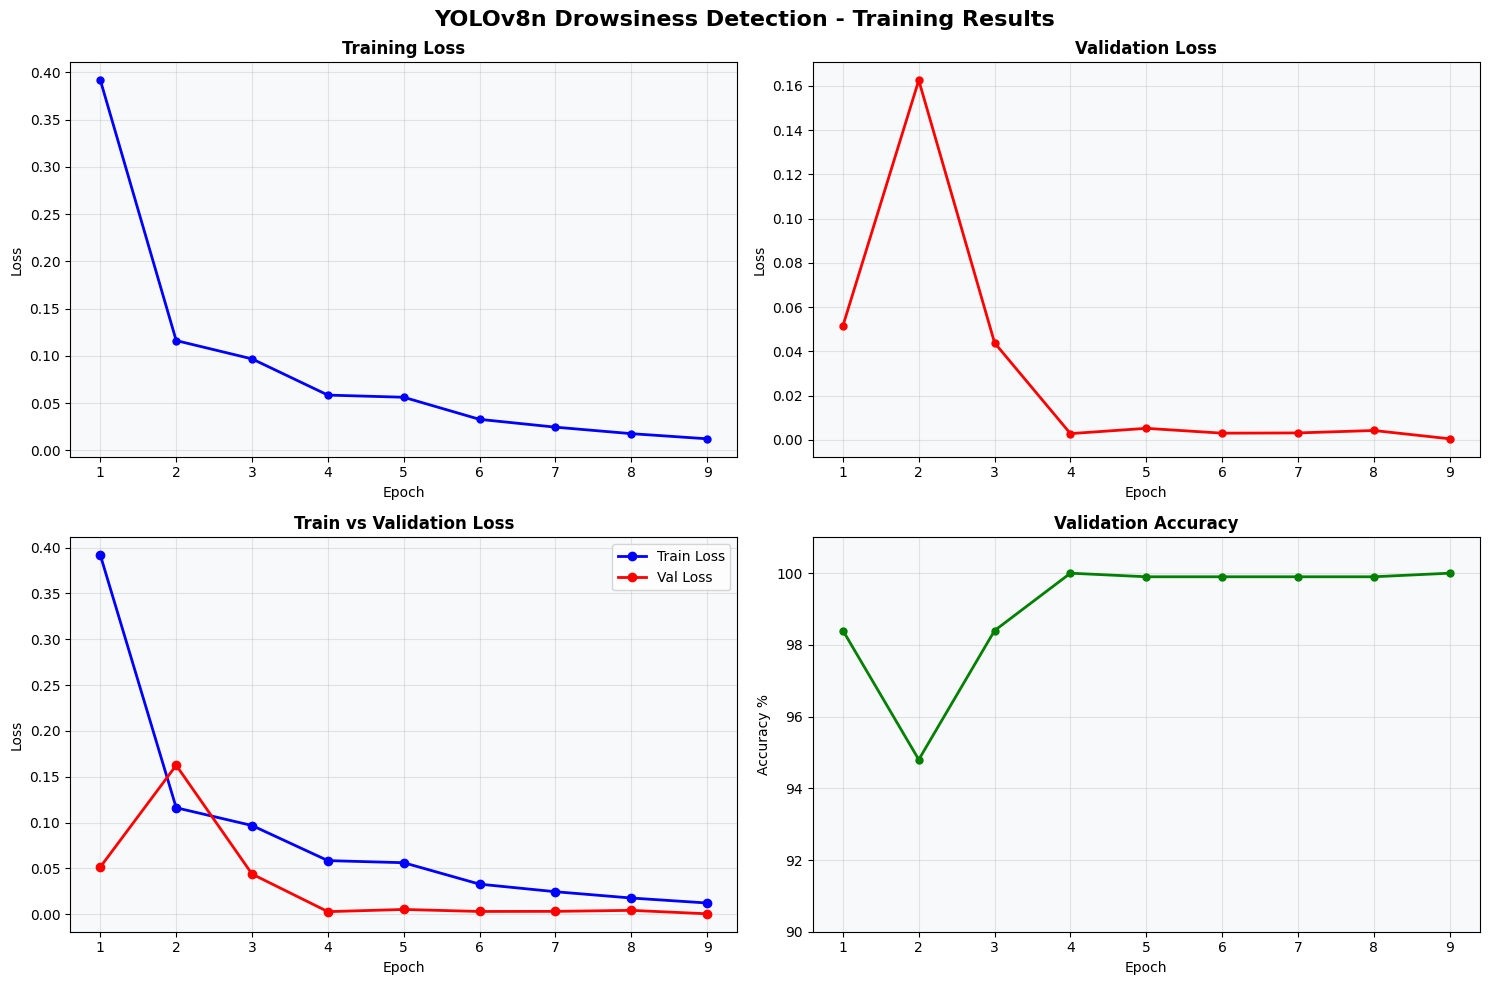

Plots saved to Drive 


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv('/content/drive/MyDrive/Drowsiness-detection/runs/drowsiness_model/results.csv')
df.columns = df.columns.str.strip()

fig = plt.figure(figsize=(15, 10))
fig.suptitle('YOLOv8n Drowsiness Detection - Training Results',
             fontsize=16, fontweight='bold')

gs = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1 — Training Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(df['epoch'], df['train/loss'], 'b-o', linewidth=2, markersize=5)
ax1.set_title('Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# Plot 2 — Validation Loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df['epoch'], df['val/loss'], 'r-o', linewidth=2, markersize=5)
ax2.set_title('Validation Loss', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f9fa')

# Plot 3 — Training vs Validation Loss
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['epoch'], df['train/loss'], 'b-o', linewidth=2, label='Train Loss')
ax3.plot(df['epoch'], df['val/loss'], 'r-o', linewidth=2, label='Val Loss')
ax3.set_title('Train vs Validation Loss', fontweight='bold')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#f8f9fa')

# Plot 4 — Accuracy
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['epoch'], df['metrics/accuracy_top1'] * 100, 'g-o', linewidth=2, markersize=5)
ax4.set_title('Validation Accuracy', fontweight='bold')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy %')
ax4.set_ylim([90, 101])
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Drowsiness-detection/training_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved to Drive ")

In [6]:
final = df.iloc[-1]
print("FINAL MODEL EVALUATION METRICS")
print(f"Epochs Trained       : {int(final['epoch'])}")
print(f"Training Loss        : {final['train/loss']:.5f}")
print(f"Validation Loss      : {final['val/loss']:.5f}")
print(f"Top-1 Accuracy       : {final['metrics/accuracy_top1']*100:.2f}%")
print(f"Top-5 Accuracy       : {final['metrics/accuracy_top5']*100:.2f}%")
print(f"Model Status         : {'Excellent ' if final['metrics/accuracy_top1'] > 0.95 else 'Good'}")

FINAL MODEL EVALUATION METRICS
Epochs Trained       : 9
Training Loss        : 0.01227
Validation Loss      : 0.00050
Top-1 Accuracy       : 100.00%
Top-5 Accuracy       : 100.00%
Model Status         : Excellent 


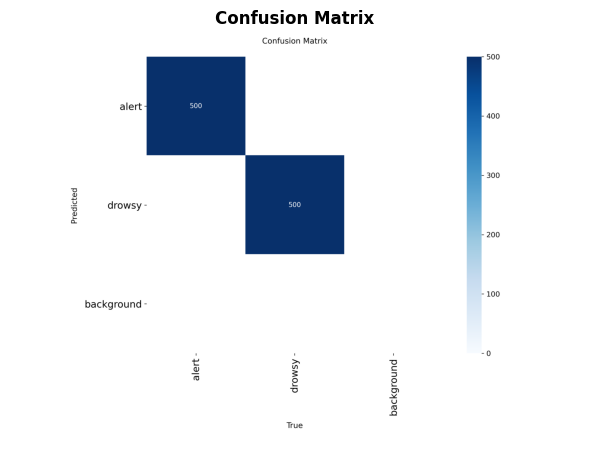

In [8]:
from IPython.display import Image
from PIL import Image as PILImage
import matplotlib.pyplot as plt

img = PILImage.open('/content/drive/MyDrive/Drowsiness-detection/runs/drowsiness_model/confusion_matrix.png')

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
import shutil

# Save confusion matrix
shutil.copy(
    '/content/drive/MyDrive/Drowsiness-detection/runs/drowsiness_model/confusion_matrix.png',
    '/content/drive/MyDrive/Drowsiness-detection/confusion_matrix.png'
)

print("All evaluation files saved to Drive")
print("\nFiles saved:")
print("→ training_plots.png")
print("→ confusion_matrix.png")

All evaluation files saved to Drive

Files saved:
→ training_plots.png
→ confusion_matrix.png
